# Inequality Constrained Optimization

Using the barrier method to handle inequality constraints with GMM.

Includes both an abstract example and a physically motivated reaction equilibrium problem.

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 11:49:49
Initial memory usage: 319.00 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

<a id='inequality'></a>
### 4.2 Inequality Constraints (Barrier Method)

For inequality constraints, we use the barrier method.

**Problem:** Minimize $(x-2)^2 + (y-1)^2$ subject to $x + y \geq 1$

In [3]:
# Scipy solution
from scipy.optimize import minimize

def f(X):
    x, y = X
    return (x - 2)**2 + (y - 1)**2

def c1(X):
    x, y = X
    return x + y - 1  # >= 0

sol = minimize(f, [1, 1], constraints={'type': 'ineq', 'fun': c1})

print("Scipy solution:")
print(f"  x = {sol.x}")
print(f"  f(x) = {sol.fun}")

Scipy solution:
  x = [2.         0.99999999]
  f(x) = 5.551115123125783e-17


In [4]:
# Barrier method with JAX
import jax.numpy as jnp
from jax import jacobian, vmap

def barrier_objective(X, mu=1e-7):
    x, y = X
    obj = (x - 2)**2 + (y - 1)**2
    barrier = -mu * jnp.log(x + y - 1)
    return obj + barrier

# Generate samples in feasible region (x + y > 1)
bounds = [[0, 3], [0, 3]]
inputs = generate_samples(bounds, n_samples=512, method='uniform', seed=42)

# Filter to feasible points
feasible = inputs[:, 0] + inputs[:, 1] > 1.01  # small margin for log
inputs = inputs[feasible]

print(f"Feasible samples: {len(inputs)}")

Feasible samples: 469


In [5]:
# Compute gradients
outputs = vmap(jacobian(barrier_objective))(inputs)
data = np.hstack([inputs, outputs])

print(f"Data shape: {data.shape}")
print("Columns: [x, y, ∂f_barrier/∂x, ∂f_barrier/∂y]")

Data shape: (469, 4)
Columns: [x, y, ∂f_barrier/∂x, ∂f_barrier/∂y]


Best model: 2 components


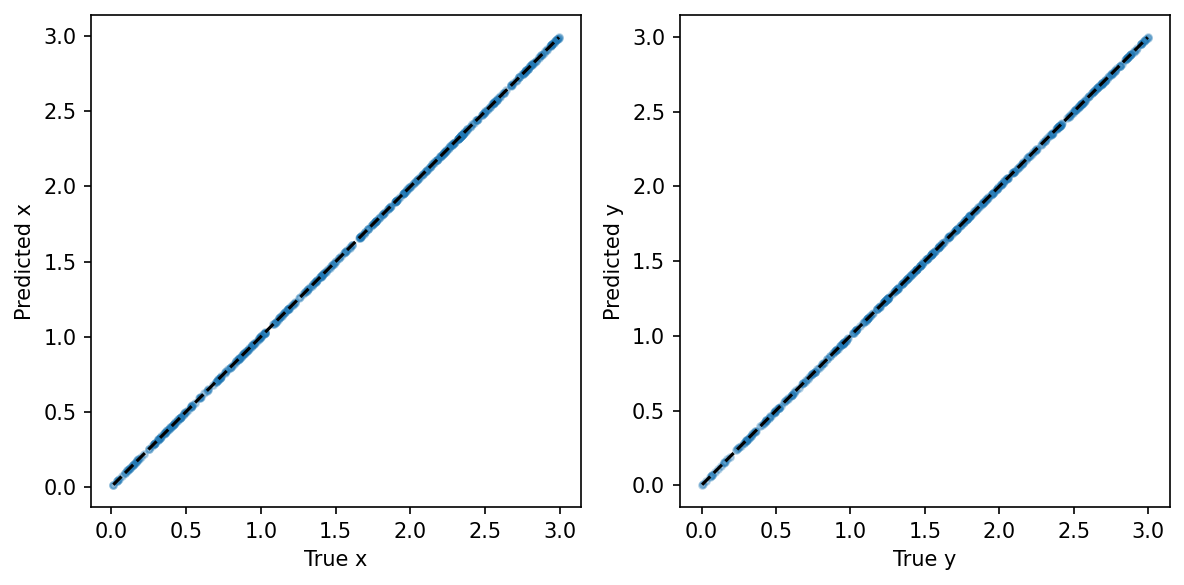

In [6]:
# Build and validate GMM
gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

# Validate
pred = gmm.predict([2, 3], data[:, 2:])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for i, (ax, label) in enumerate(zip(axes, ['x', 'y'])):
    ax.scatter(data[:, i], pred[:, i], alpha=0.3, s=10)
    lims = [data[:, i].min(), data[:, i].max()]
    ax.plot(lims, lims, 'k--')
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Predicted {label}')

plt.tight_layout()
plt.show()

In [7]:
# Solve: condition on gradient = 0
P = gmm.predict([2, 3], np.array([[0.0, 0.0]]))

print("Generative solution:")
print(f"  x = {P[0, 0]:.6f}")
print(f"  y = {P[0, 1]:.6f}")
print(f"\nExpected: x = 2.0, y = 1.0")

Generative solution:
  x = 2.000000
  y = 1.000000

Expected: x = 2.0, y = 1.0


### 4.3 Reaction Equilibrium with Barrier Method

A physically motivated example: finding the equilibrium composition of a reversible reaction $A + B \rightleftharpoons 2C$ in a batch reactor using the **barrier method**.

Given initial concentrations $C_{A0} = C_{B0} = 1$ mol/L and $C_{C0} = 0$, the concentrations evolve with extent of reaction $\xi$:
- $C_A = 1 - \xi$
- $C_B = 1 - \xi$  
- $C_C = 2\xi$

The equilibrium condition requires:
$$K_{eq} = \frac{C_C^2}{C_A \cdot C_B} = \frac{(2\xi)^2}{(1-\xi)^2}$$

**Optimization formulation:** Minimize the squared equilibrium residual:
$$\min_\xi \quad f(\xi)^2 = \left[K_{eq}(1-\xi)^2 - 4\xi^2\right]^2$$

**Inequality constraints:** Non-negative concentrations require $0 < \xi < 1$

**Barrier method:** We add logarithmic barrier terms to enforce the constraints:
$$\phi(\xi) = f(\xi)^2 - \mu \log(\xi) - \mu \log(1-\xi)$$

At the optimum, $\frac{d\phi}{d\xi} = 0$. We train a GMM on $[\xi, \frac{d\phi}{d\xi}]$ and condition on the derivative being zero.

In [8]:
# Reaction equilibrium: A + B ⇌ 2C with BARRIER METHOD
import jax
import jax.numpy as jnp
from jax import grad

# Parameters
Keq = 1.0  # Equilibrium constant
mu = 0.001  # Barrier parameter (small but not too small for numerical stability)

# Analytical solution
# Keq(1-ξ)² = 4ξ² → for Keq=1: (1-ξ)² = 4ξ² → 1-ξ = ±2ξ
# Physical root: ξ = 1/3
xi_analytical = 1/3

print("Reaction Equilibrium: A + B ⇌ 2C")
print(f"Keq = {Keq}")
print(f"Barrier parameter μ = {mu}")
print(f"\nAnalytical solution: ξ = {xi_analytical:.4f}")
print(f"Equilibrium concentrations:")
print(f"  CA = CB = {1 - xi_analytical:.4f} mol/L")
print(f"  CC = {2 * xi_analytical:.4f} mol/L")

# Verify with scipy - minimize squared residual with bounds
from scipy.optimize import minimize_scalar

def residual_squared(xi):
    f = Keq * (1 - xi)**2 - 4 * xi**2
    return f**2

result_scipy = minimize_scalar(residual_squared, bounds=(0.01, 0.99), method='bounded')
print(f"\nScipy verification (min f²): ξ = {result_scipy.x:.6f}")

Reaction Equilibrium: A + B ⇌ 2C
Keq = 1.0
Barrier parameter μ = 0.001

Analytical solution: ξ = 0.3333
Equilibrium concentrations:
  CA = CB = 0.6667 mol/L
  CC = 0.6667 mol/L

Scipy verification (min f²): ξ = 0.333334


In [9]:
# Define barrier objective function
def barrier_equilibrium(xi):
    """Barrier objective: squared residual + log barriers for 0 < ξ < 1"""
    # Equilibrium residual
    f = Keq * (1 - xi)**2 - 4 * xi**2
    # Squared residual (what we want to minimize)
    obj = f**2
    # Barrier terms to enforce 0 < ξ < 1
    barrier = -mu * jnp.log(xi) - mu * jnp.log(1 - xi)
    return obj + barrier

# Compute gradient of barrier objective
grad_barrier = grad(barrier_equilibrium)

# Generate training data: sample ξ in feasible region (0, 1)
n_samples = 2000
np.random.seed(42)
xi_samples = np.random.uniform(0.02, 0.98, n_samples)  # margin for log stability

# Compute gradients at each sample point
gradients = np.array([float(grad_barrier(float(xi))) for xi in xi_samples])

# Build joint dataset: [ξ, dφ/dξ]
data_eq = np.column_stack([xi_samples, gradients])

print(f"Training data shape: {data_eq.shape}")
print(f"Columns: [ξ, dφ/dξ]")
print(f"ξ range: [{xi_samples.min():.3f}, {xi_samples.max():.3f}]")
print(f"Gradient range: [{gradients.min():.3f}, {gradients.max():.3f}]")

# Verify: gradient should be near zero at ξ = 1/3
print(f"\nVerification: dφ/dξ at ξ=1/3: {float(grad_barrier(1/3)):.6f} (should be ≈ 0)")

Training data shape: (2000, 2)
Columns: [ξ, dφ/dξ]
ξ range: [0.023, 0.980]
Gradient range: [-4.125, 60.539]

Verification: dφ/dξ at ξ=1/3: -0.001499 (should be ≈ 0)


In [10]:
# Train GMM on [ξ, dφ/dξ]
gmm_eq, gmm_eq_info = best_gmm(data_eq, verbose=True)
print(f"\nBest GMM: {gmm_eq_info['best_k']} components")

k=1: BIC=13646.0 *
k=2: BIC=7863.8 *
k=3: BIC=4594.9 *


k=4: BIC=2323.6 *


k=5: BIC=511.8 *


k=6: BIC=-959.4 *
k=7: BIC=-1740.6 *


k=8: BIC=-2281.4 *
k=9: BIC=-3150.1 *


...

k=29: BIC=-5830.3


k=30: BIC=-5787.5


k=31: BIC=-5750.8
k=32: BIC=-5718.1


k=33: BIC=-5676.6
k=34: BIC=-5708.9


k=35: BIC=-5591.7
Early stopping at k=35

Best GMM: 25 components


In [11]:
# Solve: condition on gradient = 0 (BARRIER METHOD OPTIMIZATION)
c_gmm_eq = gmm_eq.condition([1], [[0.0]])
xi_gmm_samples = c_gmm_eq.sample(1000)[:, 0]

# Filter to valid range (some samples may be outside due to GMM tails)
xi_gmm_samples = xi_gmm_samples[(xi_gmm_samples > 0) & (xi_gmm_samples < 1)]

print("GMM Solution (conditioning on dφ/dξ = 0):")
print(f"  ξ = {xi_gmm_samples.mean():.4f} ± {xi_gmm_samples.std():.4f}")
print(f"  Analytical: ξ = {xi_analytical:.4f}")

# Verify: check residual at GMM solution
def residual_fn(xi):
    return Keq * (1 - xi)**2 - 4 * xi**2

residual_at_gmm = residual_fn(xi_gmm_samples.mean())
print(f"  |Residual| at GMM mean: {abs(residual_at_gmm):.6f}")

GMM Solution (conditioning on dφ/dξ = 0):
  ξ = 0.3345 ± 0.0012
  Analytical: ξ = 0.3333
  |Residual| at GMM mean: 0.004730


In [12]:
# Summary comparison
print("Reaction Equilibrium with Barrier Method: A + B ⇌ 2C")
print("=" * 65)
print(f"Equilibrium constant: Keq = {Keq}")
print(f"Barrier parameter: μ = {mu}")
print()

print(f"{'Method':<25} {'ξ':<15} {'|Residual|':<15}")
print("-" * 55)

# Analytical
print(f"{'Analytical':<25} {xi_analytical:<15.6f} {abs(residual_fn(xi_analytical)):<15.6f}")

# Scipy
print(f"{'Scipy (bounded)':<25} {result_scipy.x:<15.6f} {abs(residual_fn(result_scipy.x)):<15.6f}")

# GMM with barrier method
xi_gmm_mean = xi_gmm_samples.mean()
print(f"{'GMM (barrier method)':<25} {xi_gmm_mean:<15.6f} {abs(residual_fn(xi_gmm_mean)):<15.6f}")

Reaction Equilibrium with Barrier Method: A + B ⇌ 2C
Equilibrium constant: Keq = 1.0
Barrier parameter: μ = 0.001

Method                    ξ               |Residual|     
-------------------------------------------------------
Analytical                0.333333        0.000000       
Scipy (bounded)           0.333334        0.000004       
GMM (barrier method)      0.334515        0.004730       


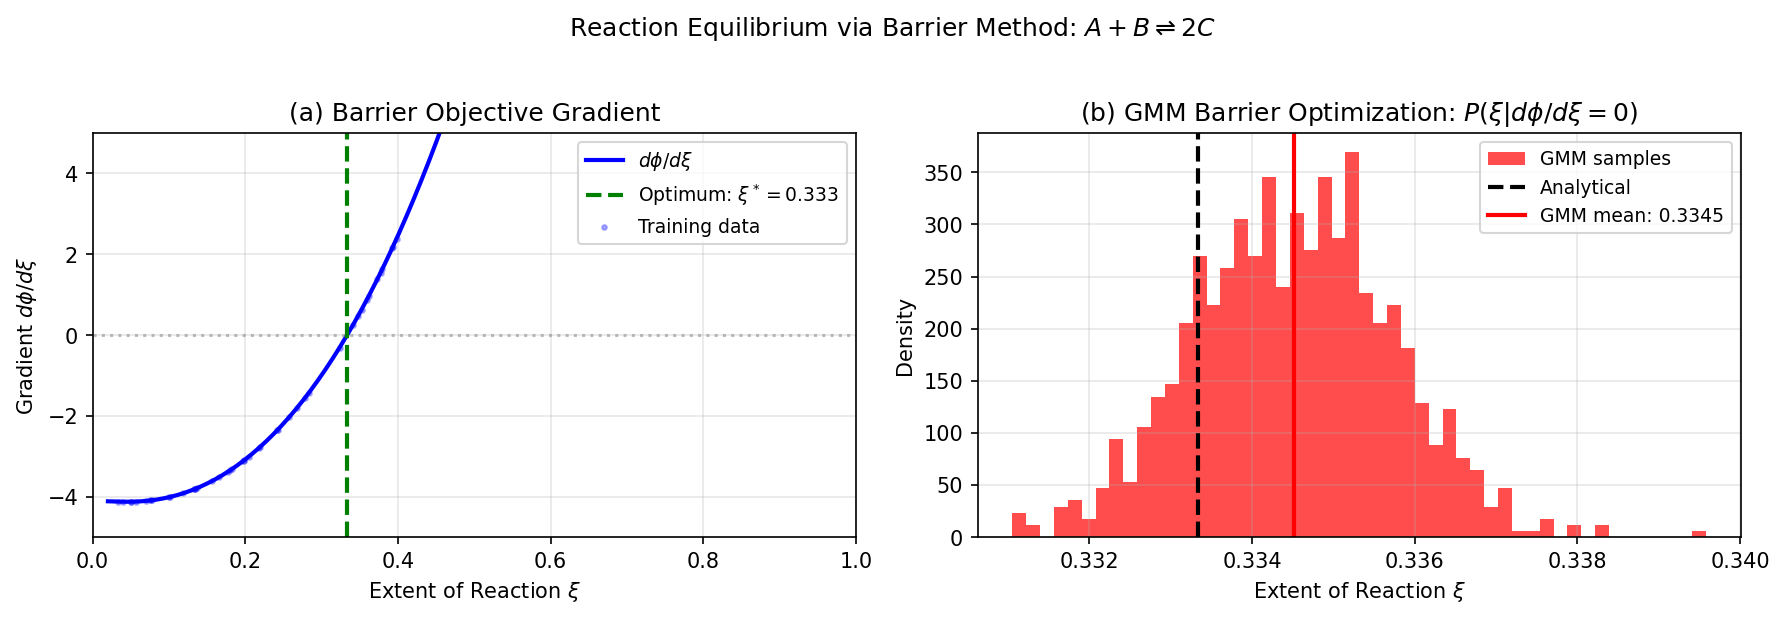

In [13]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Barrier objective and its gradient
xi_plot = np.linspace(0.02, 0.98, 200)
phi_plot = np.array([float(barrier_equilibrium(xi)) for xi in xi_plot])
grad_plot = np.array([float(grad_barrier(xi)) for xi in xi_plot])

ax1.plot(xi_plot, grad_plot, 'b-', lw=2, label='$d\\phi/d\\xi$')
ax1.axhline(0, color='gray', ls=':', alpha=0.5)
ax1.axvline(xi_analytical, color='green', ls='--', lw=2, label=f'Optimum: $\\xi^*={xi_analytical:.3f}$')
ax1.scatter(xi_samples[::20], gradients[::20], s=5, alpha=0.3, c='blue', label='Training data')

ax1.set_xlabel('Extent of Reaction $\\xi$')
ax1.set_ylabel('Gradient $d\\phi/d\\xi$')
ax1.set_title('(a) Barrier Objective Gradient')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(-5, 5)

# Right: GMM histogram
ax2.hist(xi_gmm_samples, bins=50, alpha=0.7, color='red', 
         label='GMM samples', density=True)
ax2.axvline(xi_analytical, color='black', ls='--', lw=2, label='Analytical')
ax2.axvline(xi_gmm_samples.mean(), color='red', ls='-', lw=2, 
            label=f'GMM mean: {xi_gmm_samples.mean():.4f}')

ax2.set_xlabel('Extent of Reaction $\\xi$')
ax2.set_ylabel('Density')
ax2.set_title('(b) GMM Barrier Optimization: $P(\\xi | d\\phi/d\\xi = 0)$')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Reaction Equilibrium via Barrier Method: $A + B \\rightleftharpoons 2C$', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 11:49:49
End time:        2025-12-18 11:50:03
Elapsed time:    14.21 seconds (0.24 minutes)
----------------------------------------------------------------------
Initial memory:  319.00 MB
Final memory:    597.67 MB
Memory change:   +278.67 MB
